In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

admissions = pd.read_csv(r"C:\Users\HomePC\Downloads\medoptix-analytics\database\Dataset-medoptix\admissions.csv")
metrics = pd.read_csv(r"C:\Users\HomePC\Downloads\medoptix-analytics\database\Dataset-medoptix\daily_metrics.csv")
hospitals = pd.read_csv(r"C:\Users\HomePC\Downloads\medoptix-analytics\database\Dataset-medoptix\hospitals.csv")
main_admissions = pd.read_csv(r"C:\Users\HomePC\Downloads\medoptix-analytics\database\Dataset-medoptix\main_admissions.csv")
main_metrics = pd.read_csv(r"C:\Users\HomePC\Downloads\medoptix-analytics\database\Dataset-medoptix\main_daily_metrics.csv")
wards = pd.read_csv(r"C:\Users\HomePC\Downloads\medoptix-analytics\database\Dataset-medoptix\wards.csv")


### Merge Our Data from the two sources

In [24]:
admissions = pd.concat([admissions, main_admissions], ignore_index=True)
metrics = pd.concat([metrics, main_metrics], ignore_index=True)

### Check for the inconsistencies

In [25]:
list_data = [("admissions", admissions), ("metrics", metrics), ("hospitals", hospitals), ("wards", wards)]

for name, data in list_data:
    print(name)
    print(f"{round(data.isnull().mean() * 100, 2)}\n")

    print(data.duplicated().sum())

    print(data.describe())
    print(data.describe(include=("O", "category")))
    print("-"*100)

admissions
ï»¿admission_id        98.58
date                    0.00
hospital_id             0.00
ward_code               0.00
arrival_source          0.00
triage_level           67.88
wait_minutes            0.00
length_of_stay_days     0.00
outcome                 0.00
age                     0.00
sex                     0.00
procedure_flag          0.00
admission_id            1.42
dtype: float64

1564
       ï»¿admission_id    hospital_id   wait_minutes  length_of_stay_days  \
count      2423.000000  171154.000000  171154.000000        171154.000000   
mean        322.402806       2.840775     193.467941             2.993252   
std         203.917487       1.453356      75.678446             3.069716   
min           1.000000       1.000000     -15.000000            -5.000000   
25%         152.000000       2.000000     142.000000             0.000000   
50%         303.000000       3.000000     184.000000             2.000000   
75%         474.000000       4.000000     235.000000

### Calculate Outliers using Empirical Rule and z - score
**The why and the when**

- mean
- standard deviaton

lower = mean - (3 * standard deviation)

upper = mean + (3 * standard deviation)

- anything below the lower boundary is an outlier
- anything above the boundary is an outlier

In [26]:
for name, data in list_data:
    print(name)
    for col in data.select_dtypes(include ='number').columns.to_list():
        mean = data[col].mean()
        std = data[col].std()

        lower = mean - (3 * std)
        upper = mean + (3 * std)

        outliers = data[(data[col] < lower) | (data[col] > upper)]

        print(col)
        print(len(outliers))
        print('-' * 50)
    print('_' * 50)

admissions
ï»¿admission_id
0
--------------------------------------------------
hospital_id
0
--------------------------------------------------
wait_minutes
1489
--------------------------------------------------
length_of_stay_days
918
--------------------------------------------------
age
236
--------------------------------------------------
procedure_flag
1
--------------------------------------------------
admission_id
0
--------------------------------------------------
__________________________________________________
metrics
hospital_id
0
--------------------------------------------------
base_beds
0
--------------------------------------------------
effective_capacity
0
--------------------------------------------------
occupancy
0
--------------------------------------------------
overflow
123
--------------------------------------------------
admissions
40
--------------------------------------------------
discharges
0
--------------------------------------------------
sta

### Drop irrelevant columns

In [27]:
cols_to_drop = ['ï»¿admission_id', 'ï»¿date', 'admission_id']

for name, data in list_data:
    for col in cols_to_drop:
        if col in data.columns:
            data.drop(columns = col, axis=1, inplace=True)

### Fill null values 

**The what, why and The when**

- forward fill
- backward fill
- grouped mode imputation
- KNN imputer
- Interpolation

### Deal with the Outliers

**The what, The why and The when**
- Winsorization
- Scaling /log transformation

In [28]:
admissions['triage_level'].value_counts()

triage_level
3.0    21068
4.0    15812
2.0     7897
5.0     5217
1.0     2566
3.0      947
4.0      711
2.0      338
5.0      296
1.0      128
6.5        1
abc        1
Name: count, dtype: int64

In [29]:
values_to_replace = {
    "6.5": None,
    "abc": None
}

admissions['triage_level'].replace(values_to_replace, inplace = True)

C:\Users\HomePC\AppData\Local\Temp\ipykernel_248388\2714239200.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  admissions['triage_level'].replace(values_to_replace, inplace = True)


In [30]:
admissions['triage_level'].nunique()

10

In [31]:
cols_to_fill = ['date', 'triage_level']

for name, data in list_data:
    for col in cols_to_fill:
        if 'triage_level' in data.columns:
            data['triage_level'] = data.groupby('arrival_source')['triage_level'].transform(lambda x: x.fillna(x.mode()[0]))

        if 'date' in data.columns:
            data['date'] = pd.to_datetime(data['date'], errors = 'coerce')
            data['date'] = data['date'].fillna(method='ffill')
            data['date'] = data['date'].fillna(method='bfill')
            data['date'].interpolate()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_248388\885370049.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['date'] = data['date'].fillna(method='ffill')
C:\Users\HomePC\AppData\Local\Temp\ipykernel_248388\885370049.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['date'] = data['date'].fillna(method='bfill')
C:\Users\HomePC\AppData\Local\Temp\ipykernel_248388\885370049.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['date'] = data['date'].fillna(method='ffill')
C:\Users\HomePC\AppData\Local\Temp\ipykernel_248388\885370049.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['date'] = data['date'].fil

### Handling Outliers using Winsorization Technique

In [32]:
for name, data in list_data:
    for col in data.select_dtypes(include='number').columns.to_list():

        lower = data[col].quantile(0.05)
        upper = data[col].quantile(0.95)

        data[col].clip(lower=lower, upper=upper, inplace=True)

C:\Users\HomePC\AppData\Local\Temp\ipykernel_248388\3892972364.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].clip(lower=lower, upper=upper, inplace=True)
C:\Users\HomePC\AppData\Local\Temp\ipykernel_248388\3892972364.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [33]:
admissions['arrival_source'].unique()

array(['referral', 'ambulance', 'self', 'transfer'], dtype=object)

In [34]:
for name, data in list_data:
    for col in data.select_dtypes(include=['object', 'category']).columns.to_list():
        print(data[col].value_counts())
        print('-' * 50)

ward_code
ED       54940
MED      43818
ICU      40814
SURG     31569
SURCG       13
Name: count, dtype: int64
--------------------------------------------------
arrival_source
self         102590
ambulance     31053
referral      25575
transfer      11936
Name: count, dtype: int64
--------------------------------------------------
triage_level
3.0    137242
4.0     15812
2.0      7897
5.0      5217
1.0      2566
3.0       947
4.0       711
2.0       338
5.0       296
1.0       128
Name: count, dtype: int64
--------------------------------------------------
outcome
discharged     161098
readmit_30d      4451
transferred      4290
death            1314
unknown             1
Name: count, dtype: int64
--------------------------------------------------
sex
F    85790
M    85363
X        1
Name: count, dtype: int64
--------------------------------------------------
ward_code
MED      5500
ICU      5499
ED       5475
SURG     5475
SURCG      24
Name: count, dtype: int64
---------------------

# Feature Engineering

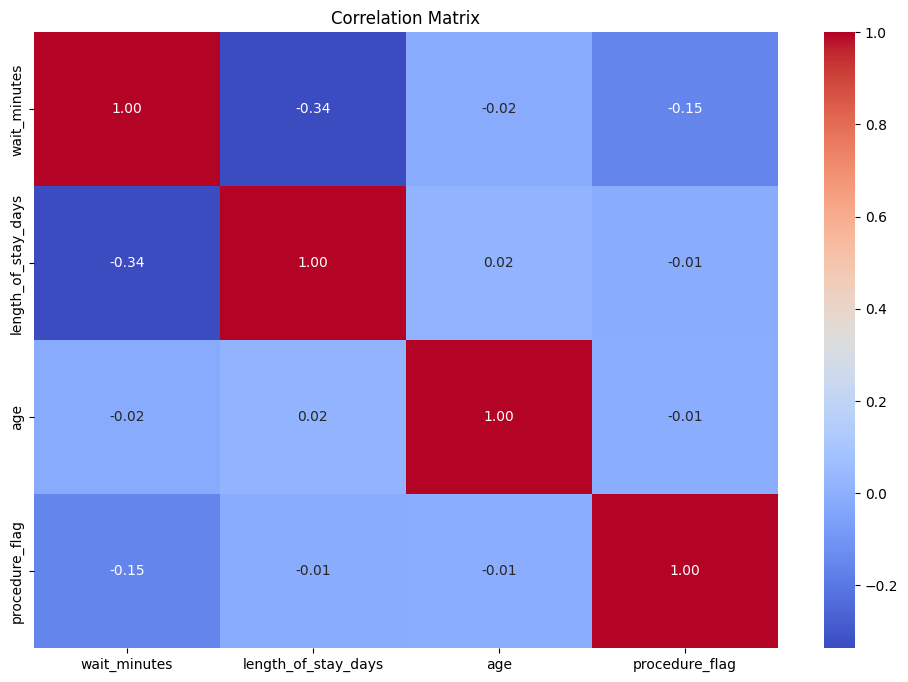

In [35]:
num_cols = admissions.select_dtypes(include='number').drop(columns=['hospital_id'])
corr = num_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Goal
Create meaningful features from admissions data that will help predict future admissions while avoiding data leakage.

### Strategy
1. **Patient-Level Features**: Calculate metrics for each admission (triage wait, bed impact)
2. **Aggregate Features**: Group by date, hospital, and ward to get daily statistics
3. **Categorical Encoding**: Convert categorical variables into count features
4. **Avoid Leakage**: Only use information that would be known at prediction time


#### Feature 1: `wait_per_triage` - Normalized Wait Time
**Purpose**: Measures how long each triage level waits, normalized by urgency

**Formula**: `wait_minutes / triage_level`

**Rationale**: 
- Triage 1 (most urgent) should wait less than Triage 5
- A 200-minute wait for Triage 1 is worse than for Triage 5
- Normalizing helps identify when urgent patients wait too long

**Handling**:
- Convert triage_level to numeric (invalid values → NaN)
- Clip outliers at 95th percentile to avoid extreme values
- Fill NaN with median to maintain data integrity

---

#### Feature 2: `bed_impact_score` - Resource Utilization Index
**Purpose**: Estimates how much hospital resources this admission will consume

**Formula**: `length_of_stay_days × (1 + procedure_flag) × (6 - triage_level)`

**Rationale**:
- Longer stays = more bed days
- Procedures increase resource needs (multiplier effect)
- Higher urgency (low triage number) = more intensive care
- Combined score predicts total resource demand

**Example**:
- ICU patient: 5 days × (1 + 1 procedure) × (6 - 1 triage) = 50 points
- ED patient: 0 days × (1 + 0) × (6 - 3) = 0 points


In [36]:
admissions['triage_level'] = pd.to_numeric(admissions['triage_level'], errors='coerce')
admissions['wait_per_triage'] = admissions['wait_minutes'] / admissions['triage_level']

admissions['wait_per_triage'] = admissions['wait_per_triage'].clip(lower=0, upper=admissions['wait_per_triage'].quantile(0.95))
admissions['wait_per_triage'] = admissions['wait_per_triage'].fillna(admissions['wait_per_triage'].median())

admissions['bed_impact_score'] = (
    admissions['length_of_stay_days'] * 
    (1 + admissions['procedure_flag']) *
    (6 - pd.to_numeric(admissions['triage_level'], errors='coerce'))
)


admissions.drop(columns=['triage_level', 'wait_minutes', 'length_of_stay_days', 'procedure_flag'], inplace=True)

In [37]:
admissions_agg = admissions.groupby(['date', 'hospital_id', 'ward_code']).agg({
    'wait_per_triage': 'mean',
    'age': 'mean',
    'bed_impact_score': 'mean'
}).reset_index()

categorical_cols = ['arrival_source', 'outcome', 'sex']

for col in categorical_cols:
    counts = (admissions.groupby(['date', 'hospital_id', 'ward_code', col])
              .size()
              .unstack(fill_value=0))
    counts.columns = [f'{col}_{c}' for c in counts.columns]
    admissions_agg = admissions_agg.merge(counts.reset_index(), 
                                          on=['date', 'hospital_id', 'ward_code'], 
                                          how='left')

admissions_agg

,date,hospital_id,ward_code,wait_per_triage,age,bed_impact_score,arrival_source_ambulance,arrival_source_referral,arrival_source_self,arrival_source_transfer,outcome_death,outcome_discharged,outcome_readmit_30d,outcome_transferred,outcome_unknown,sex_F,sex_M,sex_X
0,2022-10-28,1,ED,59.210909,54.890909,0.000,18,9,27,1,0,38,0,17,0,18,37,0
1,2022-10-28,1,ICU,34.225000,56.100000,15.000,2,0,7,1,0,9,0,1,0,4,6,0
2,2022-10-28,1,MED,37.425000,61.400000,12.600,2,1,7,0,0,10,0,0,0,4,6,0
3,2022-10-28,1,SURCG,55.125000,45.500000,0.000,1,1,0,0,0,0,0,2,0,1,1,0
4,2022-10-28,1,SURG,29.000000,61.000000,11.250,0,2,5,1,0,8,0,0,0,3,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19283,2025-10-26,4,MED,65.000000,55.500000,12.375,1,0,6,1,0,7,1,0,0,2,6,0
19284,2025-10-26,4,SURG,29.000000,47.750000,15.000,1,2,4,1,0,7,1,0,0,6,2,0
19285,2025-10-26,5,ED,71.637500,58.666667,0.000,2,2,8,0,0,12,0,0,0,5,7,0
19286,2025-10-26,5,ICU,46.666667,61.333333,22.500,0,0,3,3,0,6,0,0,0,4,2,0


### Preventing Data Leakage

**Why Lag Features?**
To predict today's admissions, we can only use information from **yesterday** or earlier.

**Lag Strategy:**
- **1-day lag**: Yesterday's metrics (recent trend)
- **7-day lag**: Last week's metrics (weekly pattern)

**Features to Lag:**
- `occupancy` → occupancy_lag1, occupancy_lag7
- `overflow` → overflow_lag1, overflow_lag7  
- `discharges` → discharges_lag1, discharges_lag7
- `avg_wait_minutes` → avg_wait_lag1, avg_wait_lag7
- `occupancy_rate` → occupancy_rate_lag1, occupancy_rate_lag7
- `admission_rate_per_bed` -> admission_rate_per_bed_lag1, admission_rate_per_bed_lag7


In [38]:
metrics = metrics.sort_values(['hospital_id', 'ward_code', 'date'])

lag_columns = ['occupancy', 'overflow', 'discharges', 'admission_rate_per_bed',
               'avg_wait_minutes', 'occupancy_rate']

for col in lag_columns:
    metrics[f'{col}_lag1'] = metrics.groupby(['hospital_id', 'ward_code'])[col].shift(1)
    metrics[f'{col}_lag7'] = metrics.groupby(['hospital_id', 'ward_code'])[col].shift(7)
    

metrics_safe = metrics.drop(columns=lag_columns)
metrics = metrics_safe.dropna()

## Merge and Save Data

In [39]:
main_data = pd.merge(admissions_agg, metrics, on=['date', 'hospital_id', 'ward_code'], how='inner')
main_data.to_csv(r"C:\Users\HomePC\Downloads\medoptix-analytics\Data\cleaned_data.csv", index=False)